# H4 Mayor frecuencia de temperaturas extremas

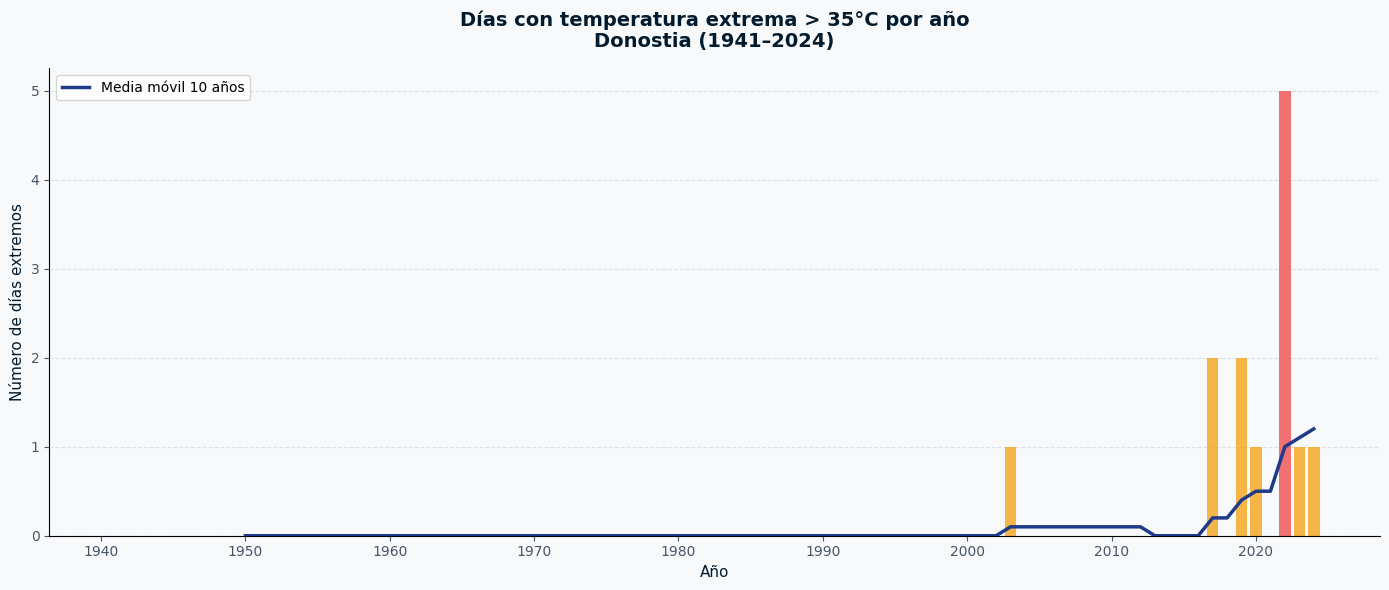

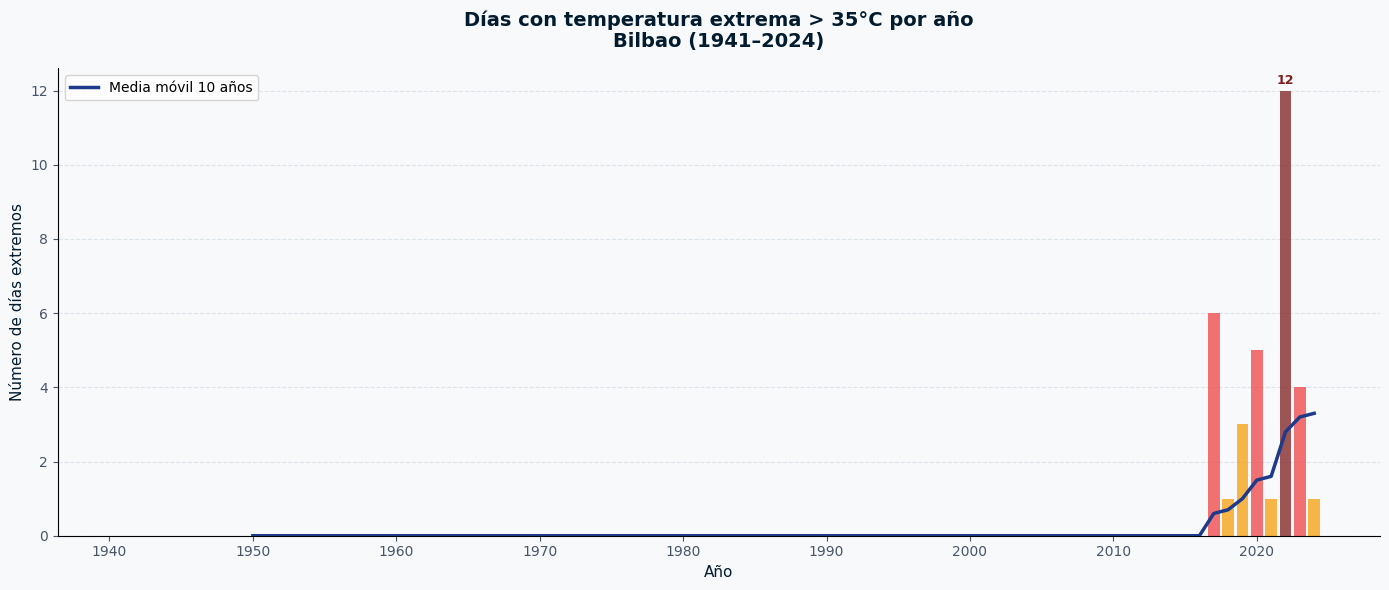

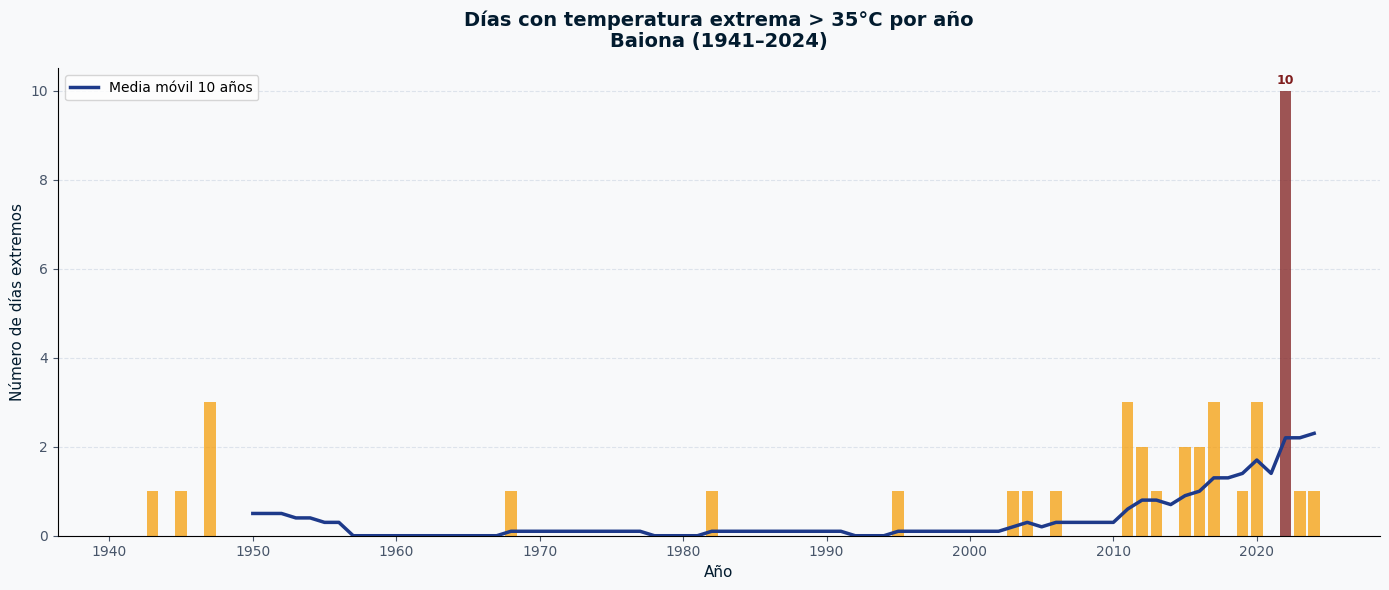

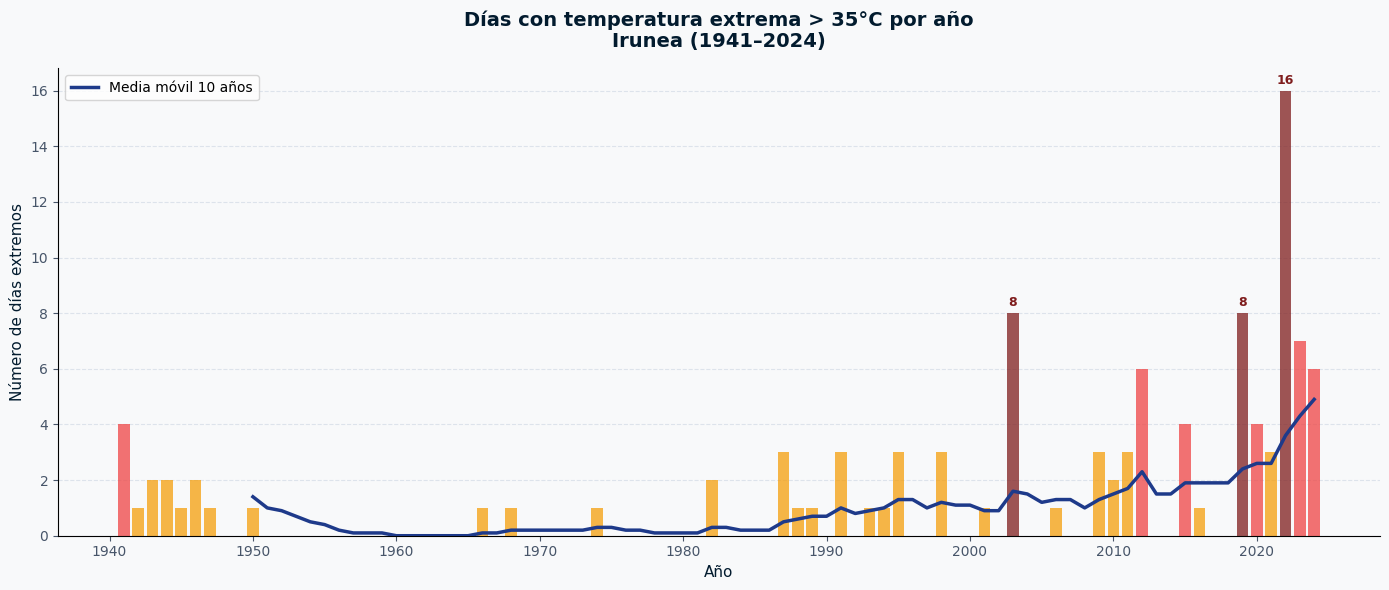

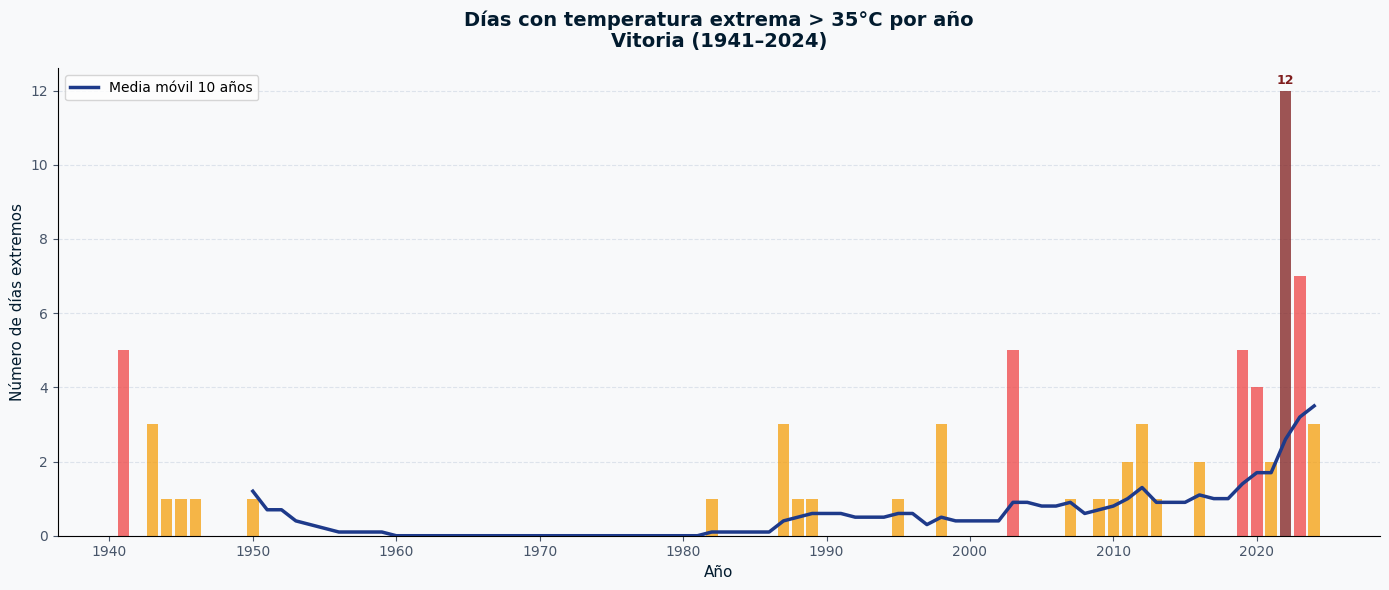

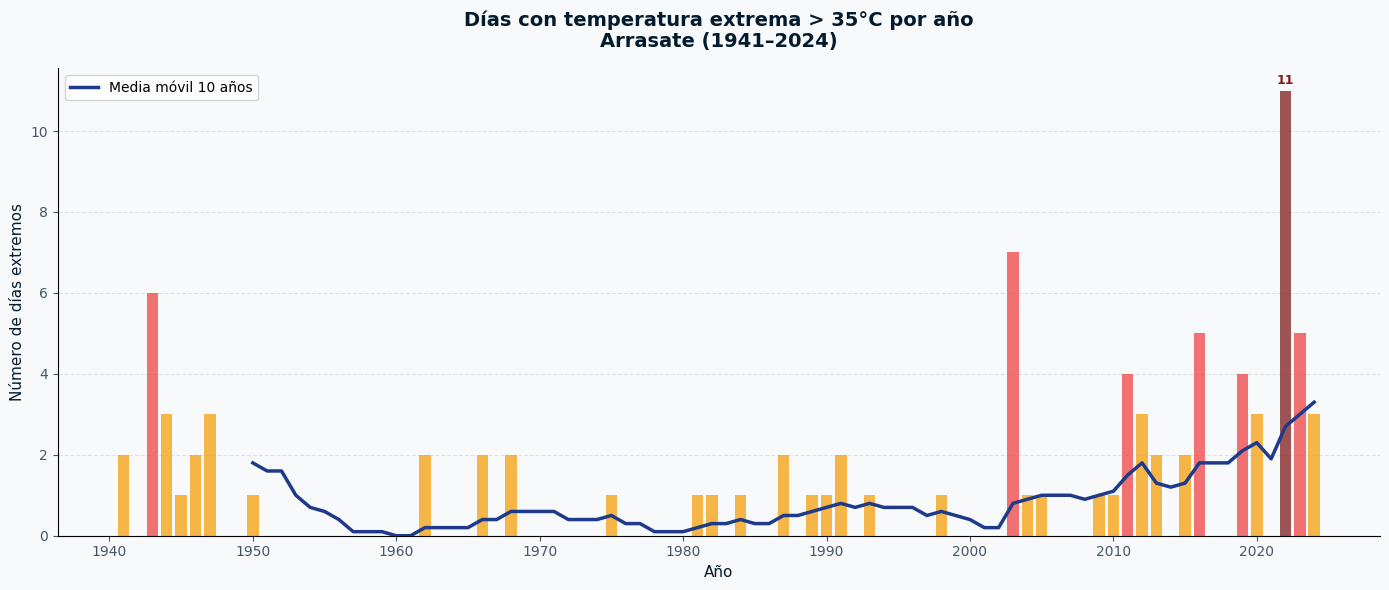

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from variables import csv_list

dfs = {}

# Cargar datos
for csv in csv_list:
    nombre = csv.split('_')[1].replace('.csv', '')
    dfs[nombre] = pd.read_csv(csv)

# EJE TEMPORAL FIJO
inicio = 1941
fin = 2024
años_fijos = list(range(inicio, fin + 1))

for csv_name in dfs:
    df = dfs[csv_name]

    # ───────────────────────────────────────────────
    # DÍAS EXTREMOS: temperatura máxima > 35°C
    # ───────────────────────────────────────────────
    df_extremos = df[df['temperature_2m_max'] > 35].groupby('año').size()

    # Rellenar años sin datos con 0
    dias = [df_extremos.get(año, 0) for año in años_fijos]

    # ───────────────────────────────────────────────
    # FIGURA
    # ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#F8F9FA')
    ax.set_facecolor('#F8F9FA')

    # Colores según intensidad del extremo
    colors = ['#F59E0B' if d <= 3 else '#EF4444' if d <= 7 else '#7F1D1D' for d in dias]

    ax.bar(años_fijos, dias, color=colors, alpha=0.75, width=0.8, zorder=2)

    # ───────────────────────────────────────────────
    # MEDIA MÓVIL (solo si hay suficientes datos)
    # ───────────────────────────────────────────────
    window = 10

    if len(dias) >= window:
        media_movil = np.convolve(dias, np.ones(window) / window, mode='valid')
        años_mm = años_fijos[window - 1:]

        ax.plot(
            años_mm,
            media_movil,
            color='#1E3A8A',
            linewidth=2.5,
            label=f'Media móvil {window} años',
            zorder=3
        )
    else:
        print(f"{csv_name}: No hay suficientes datos para calcular media móvil ({len(dias)} < {window})")

    # ───────────────────────────────────────────────
    # ESTILO
    # ───────────────────────────────────────────────
    ax.set_title(
        f'Días con temperatura extrema > 35°C por año\n{csv_name.capitalize()} (1941–2024)',
        fontsize=14,
        fontweight='bold',
        color='#021B2E',
        pad=15
    )

    ax.set_xlabel('Año', fontsize=11, color='#021B2E')
    ax.set_ylabel('Número de días extremos', fontsize=11, color='#021B2E')
    ax.tick_params(colors='#475569')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.grid(axis='y', color='#CBD5E1', linestyle='--', alpha=0.6, zorder=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=10)

    # Anotar años muy extremos (>= 8 días)
    for año, dia in zip(años_fijos, dias):
        if dia >= 8:
            ax.annotate(
                f'{dia}',
                xy=(año, dia),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                color='#7F1D1D',
                fontweight='bold'
            )

    plt.tight_layout()
    plt.savefig(f'img/extremos_35/grafico_extremos_35_{csv_name}.png', dpi=180, bbox_inches='tight')
    plt.show()

